In [7]:
# Import needed stuff.
%matplotlib notebook
import os, sys
import time
import numpy as np
import cmocean
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
pcarr = ccrs.PlateCarree()
sys.path.append("/local/tmp/jbroust/SHOOT_LIB")
from shoot.eddies.eddies2d import Ellipse, Eddies2D, EvolEddies2D, find_eddy_centers, GriddedEddy2D
from shoot.plot import create_map, pcarr
import shoot.grid as sgrid 
import shoot.dyn as sdyn
xr.set_options(display_style="text")

In [5]:
# %%
# Read data
# ---------

root_path = '/local/tmp/jbroust/DATA/DUACS_INDIEN'
path = os.path.join(root_path, 'INDIEN_avril_2025.nc')
ds= xr.open_dataset(path).isel(time=8)#.sel(latitude=slice(21,26), longitude=slice(55,65))#.isel(time=slice(8,10))#.isel(time=8)

In [10]:
ds.time

<xarray.DataArray 'time' ()> Size: 8B
array('2025-03-29T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2025-03-29
Attributes:
    axis:           T
    unit_long:      Days Since 1950-01-01
    long_name:      Time
    standard_name:  time

In [9]:
plt.figure()
ds.adt.plot(cmap='cmo.dense')

<IPython.core.display.Javascript object>

In [5]:
# Parameters of SHOOT
# ~~~~~~~~~~

# Window size in km to compute the LNAM and find eddy centers : Lb
window_center = 100

# Window size in km to fit SSH and make other diagnostics like contours : 10Rd suggested
window_fit = 150#120

# Minimal radius of an eddy to retain it
min_radius = 30

# Ellipse error
ellipse_error = 0.05#0.05  # percentage error from an ellipse

In [6]:
def def_eddy(u,v,ssh,ic, wx2c, wy2c):
    # Local selection
    i = int(centers.gi[ic])
    j = int(centers.gj[ic])
    imin = max(i - wx2c, 0)
    imax = min(i + wx2c + 1, nx)
    jmin = max(j - wy2c, 0)
    jmax = min(j + wy2c + 1, ny)
    isel = {xdim: slice(imin, imax), ydim: slice(jmin, jmax)}
    ul = u[isel]
    vl = v[isel]
    sshl = ssh[isel] if ssh is not None else None
    if isinstance(dx, xr.DataArray):
        dxl = dx[isel]
        dyl = dy[isel]
    else:
        dxl, dyl = dx, dy

    # Init eddy
    eddy = RawEddy2D(
        i - imin,
        j - jmin,
        ul,
        vl,
        ssh=sshl,
        dx=dxl,
        dy=dyl,
        max_ellipse_error=ellipse_error,
    )
    eddy.attrs.update(
        lnam=float(centers.lnam[ic]),
        coriolis=float(centers.coriolis[ic]),
        window_center=window_center,
        window_fit=window_fit,
    )
    return eddy

#### Detect centers 

In [7]:
%%time
centers = find_eddy_centers(ds.ugos, ds.vgos, window_center)
centers

CPU times: user 568 ms, sys: 11.9 ms, total: 580 ms
Wall time: 584 ms


<xarray.Dataset> Size: 748B
Dimensions:   (neddies: 17)
Coordinates:
    gi        (neddies) int64 136B 68 48 71 58 36 71 44 ... 42 51 74 60 18 28 74
    gj        (neddies) int64 136B 4 5 12 14 22 26 27 ... 10 21 21 27 29 29 30
    lon       (neddies) float32 68B 63.56 61.06 63.94 ... 57.31 58.56 64.31
    lat       (neddies) float32 68B 21.56 21.69 22.56 ... 24.69 24.69 24.81
Dimensions without coordinates: neddies
Data variables:
    lnam      (neddies) float64 136B -0.2496 -0.8637 -0.7963 ... 1.015 0.3631
    coriolis  (neddies) float32 68B 5.345e-05 5.375e-05 ... 6.075e-05 6.104e-05
    ow        (neddies) float64 136B -6.904e-12 -9.874e-11 ... -1.449e-11
Attributes:
    window:   100
    wx:       9
    wy:       9
    dx_mean:  12742.513
    dy_mean:  13899.365

In [9]:
dxdy = sgrid.get_dx_dy(ds.ugos)
dx = dxdy[0]
dy = dxdy[1]
dxm = np.nanmean(dx)
dym = np.nanmean(dy)
wx, wy = sgrid.get_wx_wy(
    window_fit, dxm, dym
)  # window on which we look for streamlines closed contours
wx2 = wx // 2
wy2 = wy // 2
print(wx2, wy2)
xdim = scf.get_xdim(ds.ugos)
ydim = scf.get_ydim(ds.ugos)

if not type(xdim) == str:
    xdim = xdim[0]
    ydim = ydim[0]

nx = ds.ugos.sizes[xdim]
ny = ds.ugos.sizes[ydim]

6 5


In [10]:
tmp_eddies = []
for ic in range(len(centers.neddies)): 
    e = def_eddy(ds.ugos, ds.vgos, ds.adt,ic, wx2, wy2)
    tmp_eddies.append(e)

In [11]:
#Tableau de correspondance des erreurs 
error = {0:'contour', 1:'radius', 3:'nan vel'}

In [12]:
eddies_val, error_val = [], [] 
for e in tmp_eddies : 
    val, err = e.is_eddy(min_radius,verbose = True)
    eddies_val.append(val)
    error_val.append(err)

In [13]:
# Local angular momentum
lnam = sdyn.get_lnam(ds.ugos, ds.vgos, window_center, dx=dxm, dy=dym)

# Mask with positive OW
ow = sdyn.get_okuboweiss(ds.ugos, ds.vgos, dx=dxm, dy=dym)
lnam = lnam.where(ow < 0)

## curl 

vort = sdyn.get_relvort(ds.ugos, ds.vgos)

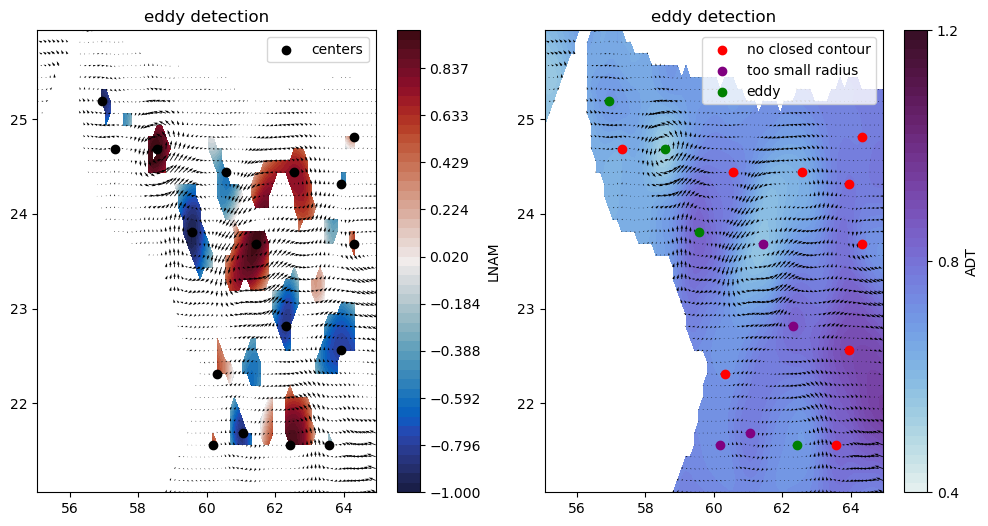

In [12]:
plt.figure(figsize=(12,6))
ax = plt.subplot(121)
plt.title("eddy detection")
cb = plt.contourf(ds.longitude, ds.latitude, lnam, cmap="cmo.balance", levels = np.linspace(-1,1,50))
plt.colorbar(cb, label = "LNAM")
nj = 1
plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
plt.scatter(centers.lon, centers.lat, c = "k", label = "centers")
plt.legend()
ax = plt.subplot(122)
plt.title("eddy detection")
cb = plt.contourf(ds.longitude, ds.latitude, ds.adt, cmap="cmo.dense",levels=np.linspace(0.4,1.2,50))
plt.colorbar(cb,label = "ADT", ticks = [0.4, 0.8, 1.2])
nj = 1
plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
rad = np.where(np.array(error_val)==1)[0]
cont = np.where(np.array(error_val)==0)[0]
plt.scatter(centers.lon[cont], centers.lat[cont], c = 'r', label= "no closed contour")
plt.scatter(centers.lon[rad], centers.lat[rad], c = "purple",label = "too small radius")
plt.scatter(centers.lon[np.array(eddies_val)], centers.lat[np.array(eddies_val)], c = "green", label = "eddy")
plt.legend()

#### Define eddies 

In [ ]:
%%time
eddies = EvolEddies2D.detect_eddies(
    ds,
    window_center,
    window_fit=window_fit,
    min_radius=min_radius,
    ssh="zos", 
    u="uo",
    v="vo",
    paral=False,
    ellipse_error=ellipse_error,
    nb_procs = 4
)

In [81]:
%%time
eddies = Eddies2D.detect_eddies(
    ds.ugos,
    ds.vgos,
    window_center,
    window_fit=window_fit,
    min_radius=min_radius,
    ssh=ds.adt,
    paral=False,
    ellipse_error=ellipse_error,
    nb_procs = 4
)   

Running in sequential way
CPU times: user 3.97 s, sys: 7.39 ms, total: 3.98 s
Wall time: 3.99 s


In [57]:
%%time
eddies_nossh = Eddies2D.detect_eddies(
    ds.ugos,
    ds.vgos,
    window_center,
    window_fit=window_fit,
    min_radius=min_radius,
    paral=False,
    ellipse_error=ellipse_error,
    nb_procs = 4
)   

Running in sequential way
CPU times: user 2.98 s, sys: 14.1 ms, total: 3 s
Wall time: 3.03 s


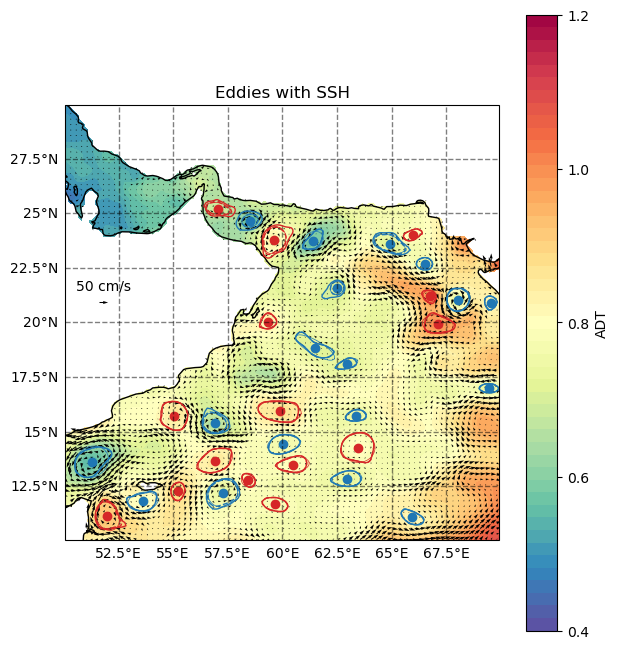

In [85]:
fig, ax = plt.subplots(1, subplot_kw=dict(projection=pcarr), figsize=(7,8))
ax.set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])
ax.gridlines(
    draw_labels=["bottom", "left"],
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--',
    rotate_labels=False,
)
ax.coastlines()
#ax = plt.subplot(121)
plt.title("Eddies with SSH")
cb = plt.contourf(ds.longitude, ds.latitude, ds.adt, cmap="Spectral_r",levels=np.linspace(0.4,1.2,50))
plt.colorbar(cb,label = "ADT", ticks = [0.4, 0.6, 0.8, 1, 1.2], orientation="vertical")
nj = 2
qv = plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
plt.quiverkey(qv, 0.18,0.52, 0.5, "50 cm/s", coordinates = 'figure')
for i, eddy in enumerate(eddies.eddies):
    if eddy :
        eddy.plot(boundary = True, vmax = True)
plt.savefig("/home/shom/jbroust/Documents/OUTPUTS/SHOOT/for_paper/indian_exemple.png")

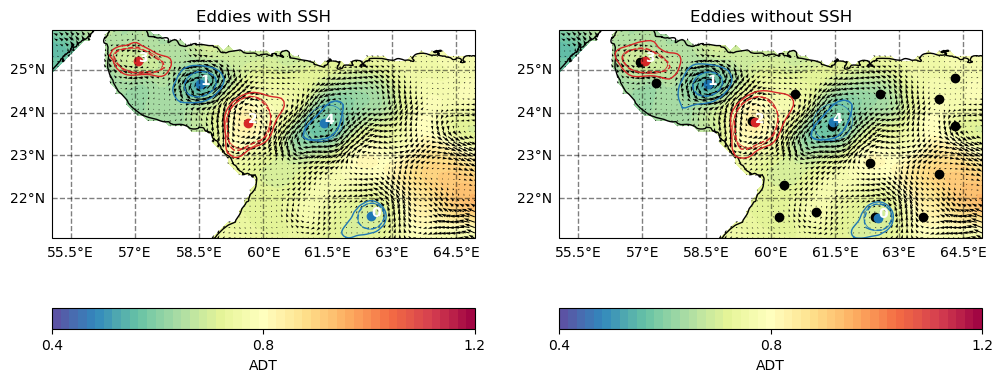

In [78]:
#plt.figure(figsize=(12,6))
fig, ax = plt.subplots(1, 2, subplot_kw=dict(projection=pcarr), figsize=(12,6))
plt.sca(ax[0])
ax[0].set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])
ax[0].gridlines(
    draw_labels=["bottom", "left"],
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--',
    rotate_labels=False,
)
ax[0].coastlines()
#ax = plt.subplot(121)
plt.title("Eddies with SSH")
cb = plt.contourf(ds.longitude, ds.latitude, ds.adt, cmap="Spectral_r",levels=np.linspace(0.4,1.2,50))
plt.colorbar(cb,label = "ADT", ticks = [0.4, 0.8, 1.2], orientation="horizontal")
nj = 1
plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
#plt.scatter(centers.lon, centers.lat, c = "k")
for i, eddy in enumerate(eddies.eddies):
    if eddy :
        eddy.plot(boundary = True, vmax = True)
        plt.text(eddy.lon,eddy.lat, "%i"%i, fontweight = 'bold', color = "w")

plt.sca(ax[1])
ax[1].set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])
ax[1].gridlines(
    draw_labels=["bottom", "left"],
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--',
    rotate_labels=False,
)
ax[1].coastlines()
plt.title("Eddies without SSH")
cb = plt.contourf(ds.longitude, ds.latitude, ds.adt, cmap="Spectral_r",levels=np.linspace(0.4,1.2,50))
plt.colorbar(cb,label = "ADT", ticks = [0.4, 0.8, 1.2], orientation="horizontal")
nj = 1
plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
plt.scatter(centers.lon, centers.lat, c = "k")
for i, eddy in enumerate(eddies_nossh.eddies):
    if eddy :
        eddy.plot(boundary = True, vmax = True)
        plt.text(eddy.lon,eddy.lat, "%i"%i, fontweight = 'bold', color = "w")
plt.savefig("/home/shom/jbroust/Documents/OUTPUTS/SHOOT/for_paper/ssh_sensitivity.png")

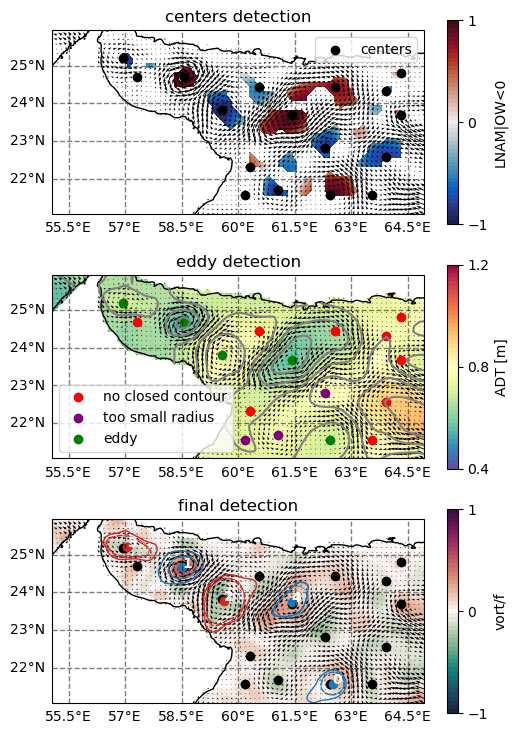

In [64]:
fig, ax = plt.subplots(3, 1, subplot_kw=dict(projection=pcarr), figsize=(6,9))

plt.sca(ax[0])
ax[0].set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])
ax[0].gridlines(
    draw_labels=["bottom", "left"],
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--',
    rotate_labels=False,
)
ax[0].coastlines()

plt.title("centers detection")
cb = plt.contourf(ds.longitude, ds.latitude, lnam, cmap="cmo.balance", levels = np.linspace(-1,1,50))
plt.colorbar(cb, label = "LNAM|OW<0", ticks = [-1,0,1])
nj = 1
qv = plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
plt.scatter(centers.lon, centers.lat, c = "k", label = "centers")
plt.legend()

plt.sca(ax[1])
ax[1].set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])
ax[1].gridlines(
    draw_labels=["bottom", "left"],
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--',
    rotate_labels=False,
)
ax[1].coastlines()
plt.title("eddy detection")
cb = plt.contourf(ds.longitude, ds.latitude, ds.adt, cmap="Spectral_r",levels=np.linspace(0.4,1.2,50))
plt.contour(ds.longitude, ds.latitude, ds.adt, colors = "gray")
plt.colorbar(cb,label = "ADT [m]", ticks = [0.4, 0.8, 1.2])
nj = 1
plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
rad = np.where(np.array(error_val)==1)[0]
cont = np.where(np.array(error_val)==0)[0]
plt.scatter(centers.lon[cont], centers.lat[cont], c = 'r', label= "no closed contour")
plt.scatter(centers.lon[rad], centers.lat[rad], c = "purple",label = "too small radius")
plt.scatter(centers.lon[np.array(eddies_val)], centers.lat[np.array(eddies_val)], c = "green", label = "eddy")
plt.legend()
plt.yticks([],[])

plt.sca(ax[2])
ax[2].set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])
ax[2].gridlines(
    draw_labels=["bottom", "left"],
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--',
    rotate_labels=False,
)
ax[2].coastlines()
plt.title("final detection")
import xoa.coords as xcoords
corio = sdyn.get_coriolis(xcoords.get_lat(ds.adt))
cb = plt.contourf(ds.longitude, ds.latitude, vort/corio, cmap="cmo.curl",levels=np.linspace(-1,1,50))
plt.colorbar(cb,label = "vort/f", ticks = [-1,0,1])
nj = 1
plt.quiver(
    ds.longitude.values[::nj,],
    ds.latitude.values[::nj],
    ds.ugos.values[::nj, ::nj],
    ds.vgos.values[::nj, ::nj],
)
plt.scatter(centers.lon, centers.lat, c = "k")
for i, eddy in enumerate(eddies.eddies):
    if eddy :
        eddy.plot(boundary = True, vmax = True)
        plt.text(eddy.lon,eddy.lat, "%i"%i, fontweight = 'bold', color = "w")
plt.yticks([],[])
plt.savefig("/home/shom/jbroust/Documents/OUTPUTS/SHOOT/for_paper/detections_steps.png")

### Test ellipse fitting

In [36]:
import shoot.geo as sgeo
from scipy.optimize import least_squares
import xoa.geo as xgeo
def _residuals(params, points):
    """return distance to theoretical ellipse"""
    xc, yc, a, b, theta = params
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    shifted = points - [xc, yc]
    rotated = shifted @ R
    normed = rotated / [a, b]
    distances = np.linalg.norm(normed, axis=1)
    return distances - 1
    
def fit_ellipse_from_coords(lons, lats, get_fit=False):
    """Fit an allipse to a contour line
    Parameters
    ----------
    lons: array(npts)
        Longitudes in degrees
    lats: array(npts)
        Latitudes in degrees

    get_fit: boolean (optional)
        True if error metric is wanted

    Returns
    -------
    dict:
        lon: center lon in degrees
        lat: center lat in degrees
        a: semi-major axis in km
        b: semi-minor axis in km
        angle: angle in degrees
    """

    lons = np.array(lons)
    lats = np.array(lats)

    lon0 = lons.mean()
    lat0 = lats.mean()

    x = sgeo.deg2m(lons - lon0, lat0)
    y = sgeo.deg2m(lats - lat0)

    points = np.column_stack((x, y))

    # 4. Estimation initiale simple
    xc0, yc0 = np.mean(points, axis=0)
    a0, b0 = (np.ptp(points, axis=0)) / 2
    theta0 = 0.0
    x0 = [xc0, yc0, a0, b0, theta0]

    # 5. Fit avec least_squares
    result = least_squares(_residuals, x0, args=(points,))
    xc, yc, a, b, theta = result.x
    error = np.mean(result.fun**2)

    lat = lat0 + sgeo.m2deg(yc)
    lon = lon0 + sgeo.m2deg(xc, lat=lat0)

    if b > a:
        a, b = b, a
        theta += np.pi / 2

    out = dict(lon=lon, lat=lat, a=a / 1e3, b=b / 1e3, angle=np.degrees(theta))
    if get_fit:
        out = out, error
    return out
    
def sample(result):

    theta = np.radians(result['angle'])
    ca = np.cos(theta)
    sa = np.sin(theta)

    angles = np.linspace(0, 360.0, 100)
    alphas = np.radians(angles)
    cas = np.cos(alphas)
    sas = np.sin(alphas)

    am = result['a'] * 1e3
    bm = result['b'] * 1e3


    lons = result['lon'] + xgeo.m2deg(am * ca * cas - bm * sa * sas, result['lat'])
    lats = result['lat'] + xgeo.m2deg(am * sa * cas + bm * ca * sas)
    return lons, lats

In [37]:
eddy = eddies.eddies[4]
print(eddy.lon, eddy.lat)
lons = eddy.vmax_contour.lon
lats = eddy.vmax_contour.lat
result, error = fit_ellipse_from_coords(lons, lats, get_fit=True)
error, result

61.56865011622768 23.84977658291791


(np.float64(0.05653608025976644),
 {'lon': np.float64(61.56865011622768),
  'lat': np.float64(23.84977658291791),
  'a': np.float64(92.15259604650946),
  'b': np.float64(75.69506026187484),
  'angle': np.float64(43.031714483664686)})

In [40]:
x,y = sample(result)
x

array([62.23100452, 62.19745723, 62.16137797, 62.12291199, 62.0822142 ,
       62.03944847, 61.994787  , 61.94840963, 61.9005031 , 61.85126031,
       61.80087956, 61.74956369, 61.69751935, 61.64495611, 61.5920856 ,
       61.53912073, 61.48627476, 61.43376049, 61.38178937, 61.33057067,
       61.28031064, 61.23121164, 61.18347139, 61.13728213, 61.09282982,
       61.05029348, 61.00984438, 60.97164539, 60.93585033, 60.90260333,
       60.87203826, 60.84427821, 60.81943494, 60.7976085 , 60.77888677,
       60.76334514, 60.75104619, 60.74203945, 60.73636117, 60.73403422,
       60.73506798, 60.73945828, 60.74718744, 60.75822435, 60.77252455,
       60.79003047, 60.81067161, 60.83436487, 60.86101483, 60.89051419,
       60.92274417, 60.95757498, 60.99486638, 61.0344682 , 61.07622098,
       61.1199566 , 61.16549895, 61.21266465, 61.26126377, 61.31110063,
       61.36197456, 61.41368069, 61.46601083, 61.51875426, 61.5716986 ,
       61.62463067, 61.67733733, 61.72960634, 61.78122724, 61.83

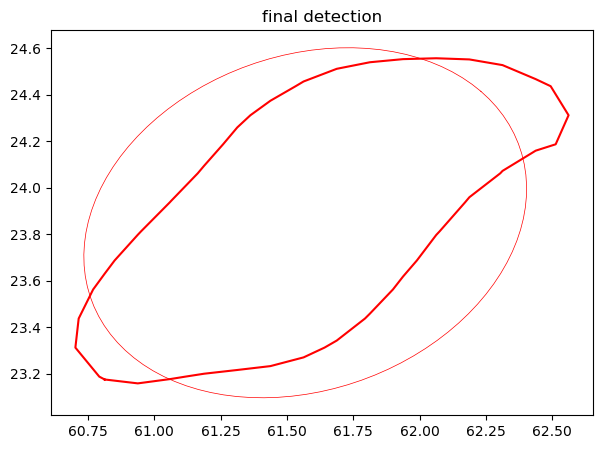

In [41]:
plt.figure(figsize=(7,5))
ax = plt.subplot(111)
plt.title("final detection")

plt.plot(lons, lats, c  ='r')
plt.plot(x,y, c = "r", linewidth = 0.5)